<a href="https://colab.research.google.com/github/FangLinSun/Chemistry-Data-Analysis/blob/main/Cheminformatics_ESOL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 46.2 MB/s eta 0:00:00


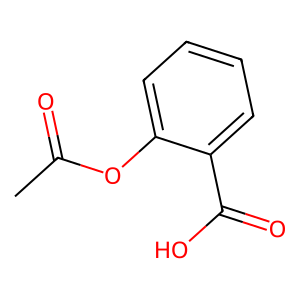

In [4]:
# 导入刚刚安装好的工具包
from rdkit import Chem
from rdkit.Chem import Draw

# 告诉计算机阿司匹林的 SMILES 密码
aspirin = Chem.MolFromSmiles('CC(=O)OC1=CC=CC=C1C(=O)O')

# 让计算机画图
img = Draw.MolToImage(aspirin, size=(300, 300))

# 显示图片
img

In [5]:
# 1. 导入专门负责计算分子描述符（属性）的工具
from rdkit.Chem import Descriptors

# 注意：这里我们直接沿用上一个框里已经定义好的变量 'aspirin'
# 不需要重新写 SMILES 代码，这就是编程的方便之处

# 2. 计算阿司匹林的精确分子量
# 我们调用 Descriptors 下的 ExactMolWt 函数
mw = Descriptors.ExactMolWt(aspirin)

# 3. 计算阿司匹林的 LogP 值
# 我们调用 Descriptors 下的 MolLogP 函数
logp = Descriptors.MolLogP(aspirin)

# 4. 将结果精美地打印出来
print("--- 阿司匹林属性分析报告 ---")
print(f"1. 精确分子量 (MW): {mw:.2f} g/mol") # .2f 表示保留两位小数
print(f"2. 脂水分配系数 (LogP): {logp:.2f}")

--- 阿司匹林属性分析报告 ---
1. 精确分子量 (MW): 180.04 g/mol
2. 脂水分配系数 (LogP): 1.31


In [6]:
# 1. 导入化学工具，以及我们的“超级Excel”工具 Pandas
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

# 2. 建立我们的“待测分子清单” (包含了三大常见解热镇痛药)
# 这就像是你发给电脑的任务单
molecule_list = [
    {"名称": "阿司匹林", "SMILES": "CC(=O)OC1=CC=CC=C1C(=O)O"},
    {"名称": "扑热息痛", "SMILES": "CC(=O)NC1=CC=C(O)C=C1"},
    {"名称": "布洛芬", "SMILES": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"}
]

# 3. 准备一个空盒子，用来装计算好的结果
results = []

# 4. 核心魔法：启动 For 循环流水线！
# 这句话的意思是：对于清单里的每一个分子，依次执行下面的操作
for item in molecule_list:

    # 提取分子的名字和密码
    name = item["名称"]
    smiles = item["SMILES"]

    # 把密码变成计算机认识的分子
    mol = Chem.MolFromSmiles(smiles)

    # 计算分子量和 LogP
    mw = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)

    # 把算好的数据打包，扔进我们刚才准备的空盒子里
    # round(mw, 2) 的意思是保留两位小数
    results.append({
        "分子名称": name,
        "分子量 (MW)": round(mw, 2),
        "脂水分配系数 (LogP)": round(logp, 2)
    })

# 5. 把装满结果的盒子，转换成 Pandas 超级表格，并展示出来
df = pd.DataFrame(results)
df

,分子名称,分子量 (MW),脂水分配系数 (LogP)
0,阿司匹林,180.04,1.31
1,扑热息痛,151.06,1.35
2,布洛芬,206.13,3.07


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. 从网络上直接读取真实的化学数据集 (CSV格式)
# 这个链接指向一个包含了1144个分子的水溶性数据集 (ESOL)
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
print("正在下载数据集...")
df = pd.read_csv(url)

# 2. 看看这个庞大的表格长什么样（只显示前5行）
print("下载完成！数据集前5行预览：")
display(df.head())

# 3. 让 Pandas 帮我们算算，这表里到底有多少个分子？
total_molecules = len(df)
print(f"\n这个数据集里一共包含 {total_molecules} 个分子！")

正在下载数据集...
下载完成！数据集前5行预览：


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1



这个数据集里一共包含 1128 个分子！


In [8]:
# 提取我们需要画图的三列数据
mw = df['Molecular Weight']
logp = df['MolLogP']
solubility = df['measured log solubility in mols per litre']

# 设置画图的尺寸和风格
plt.figure(figsize=(10, 6))

# 画散点图
# x=分子量, y=LogP, c=颜色对应水溶性, cmap=颜色主题(这里选了漂亮的冷暖色调)
scatter = plt.scatter(mw, logp, c=solubility, cmap='coolwarm', alpha=0.7, edgecolors='w', linewidth=0.5)

# 添加颜色条，说明颜色代表的含义
cbar = plt.colorbar(scatter)
cbar.set_label('Measured Log Solubility (水溶性)', rotation=270, labelpad=20)

# 添加标题和坐标轴标签
plt.title('1144个药物分子的化学属性空间分布 (ESOL Dataset)', fontsize=14, pad=15)
plt.xlabel('Molecular Weight (分子量)', fontsize=12)
plt.ylabel('MolLogP (脂水分配系数)', fontsize=12)

# 画几条参考线（里宾斯基法则的边界）
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='MW = 500 限值')
plt.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='LogP = 5 限值')
plt.legend()

# 显示这张图！
plt.grid(True, alpha=0.3)
plt.show()

KeyError: 'MolLogP'

import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. 重新读取网络上的数据集
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

# 2. 核心魔法：原表里没有 LogP？我们自己算！
print("发现原数据缺失 LogP，正在呼叫 RDKit 紧急计算 1144 个分子的 LogP...")
# 这行代码的意思是：对表格里每一个 SMILES 密码，自动把它变成化学分子，并算出 LogP
df['MolLogP'] = df['smiles'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)))
print("计算全部完成！准备生成空间分布图...")

# 3. 提取画图需要的数据（现在表格里有 MolLogP 这一列了！）
mw = df['Molecular Weight']
logp = df['MolLogP']
solubility = df['measured log solubility in mols per litre']

# 4. 画极其专业的散点图
plt.figure(figsize=(10, 6))
scatter = plt.scatter(mw, logp, c=solubility, cmap='coolwarm', alpha=0.7, edgecolors='w', linewidth=0.5)

# 添加颜色条
cbar = plt.colorbar(scatter)
cbar.set_label('Measured Log Solubility (水溶性)', rotation=270, labelpad=20)

# 添加标题和标签
plt.title('1144个药物分子的化学属性空间分布', fontsize=14, pad=15)
plt.xlabel('Molecular Weight (分子量)', fontsize=12)
plt.ylabel('MolLogP (脂水分配系数)', fontsize=12)

# 画安全区参考线
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='MW = 500 限值')
plt.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='LogP = 5 限值')
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()

发现原数据缺失 LogP，正在呼叫 RDKit 紧急计算 1144 个分子的 LogP...
计算全部完成！准备生成空间分布图...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33026 (\N{CJK UNIFIED IDEOGRAPH-8102}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  fig.canvas

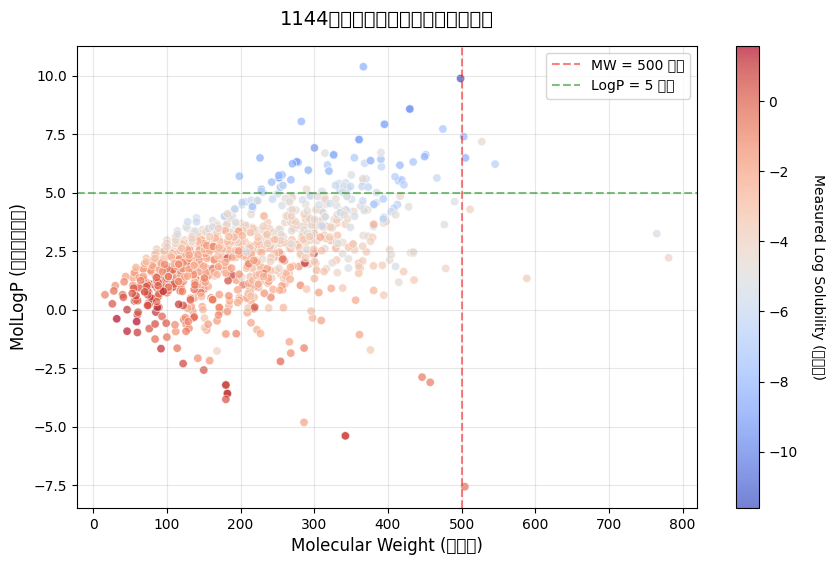

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. 重新读取网络上的数据集
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

# 2. 核心魔法：原表里没有 LogP？我们自己算！
print("发现原数据缺失 LogP，正在呼叫 RDKit 紧急计算 1144 个分子的 LogP...")
# 这行代码的意思是：对表格里每一个 SMILES 密码，自动把它变成化学分子，并算出 LogP
df['MolLogP'] = df['smiles'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)))
print("计算全部完成！准备生成空间分布图...")

# 3. 提取画图需要的数据（现在表格里有 MolLogP 这一列了！）
mw = df['Molecular Weight']
logp = df['MolLogP']
solubility = df['measured log solubility in mols per litre']

# 4. 画极其专业的散点图
plt.figure(figsize=(10, 6))
scatter = plt.scatter(mw, logp, c=solubility, cmap='coolwarm', alpha=0.7, edgecolors='w', linewidth=0.5)

# 添加颜色条
cbar = plt.colorbar(scatter)
cbar.set_label('Measured Log Solubility (水溶性)', rotation=270, labelpad=20)

# 添加标题和标签
plt.title('1144个药物分子的化学属性空间分布', fontsize=14, pad=15)
plt.xlabel('Molecular Weight (分子量)', fontsize=12)
plt.ylabel('MolLogP (脂水分配系数)', fontsize=12)

# 画安全区参考线
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='MW = 500 限值')
plt.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='LogP = 5 限值')
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()

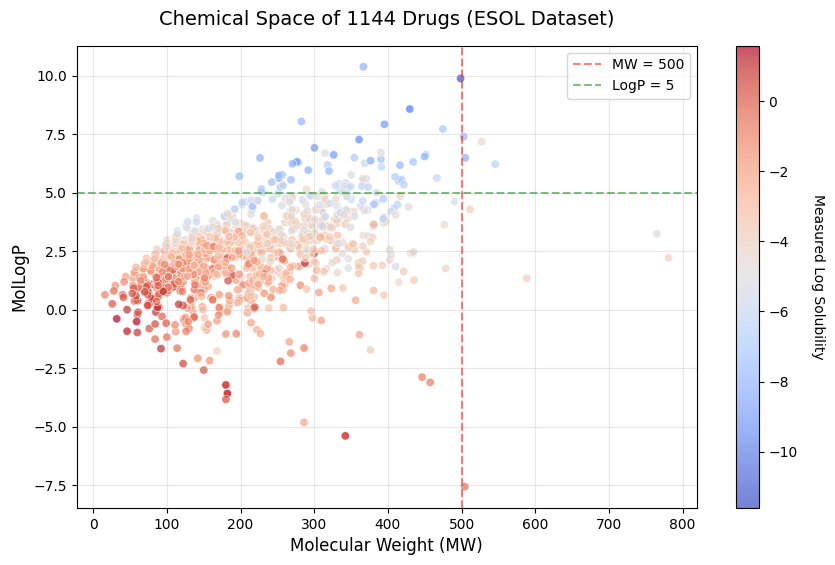

In [10]:
# 重新设置画图的尺寸
plt.figure(figsize=(10, 6))

# 画散点图
scatter = plt.scatter(mw, logp, c=solubility, cmap='coolwarm', alpha=0.7, edgecolors='w', linewidth=0.5)

# 添加颜色条
cbar = plt.colorbar(scatter)
cbar.set_label('Measured Log Solubility', rotation=270, labelpad=20)

# 【关键修改】全部换成专业的英文学术标签
plt.title('Chemical Space of 1144 Drugs (ESOL Dataset)', fontsize=14, pad=15)
plt.xlabel('Molecular Weight (MW)', fontsize=12)
plt.ylabel('MolLogP', fontsize=12)

# 画安全区参考线
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='MW = 500')
plt.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='LogP = 5')
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()